# 🕸️ LangGraph 101: Up-to-Date Guide to Stateful Agentic Systems

Welcome to **LangGraph 101**! This tutorial covers all modern, up-to-date concepts of **LangGraph** (v1.2+) using **local Ollama models** (`nemotron-3-nano:4b`, `gemma4:e2b`, and `nomic-embed-text:latest`).

### 🎯 Learning Objectives:
1. **Core Architecture**: `StateGraph`, `START`, `END`, `MessagesState`, and State Reducers.
2. **Nodes & Edges**: Defining graph nodes, linear transitions, and conditional routing.
3. **Cyclic ReAct Agent Graph**: Building custom tool-calling agents with `ToolNode` and `tools_condition`.
4. **State Persistence & Memory**: Session thread management with `MemorySaver` checkpointers.
5. **Human-in-the-Loop (HITL)**: Pausing execution using `interrupt_before`, state inspection, and human approval.
6. **Time Travel & State Revision**: Rewinding execution history and editing state checkpoints with `update_state()`.
7. **Multi-Agent Orchestration**: Building a Supervisor-Worker multi-agent system.


--- 
## 0. Setup & Local Model Verification

Let's import LangGraph, LangChain, and initialize our local Ollama model instance.

In [1]:
import os
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.chat_models import init_chat_model

# Select local Ollama model
MODEL_NAME = "nemotron-3-nano:4b"  # Or "gemma4:e2b"
EMBED_MODEL = "nomic-embed-text:latest"

# llm = ChatOllama(
#     model=MODEL_NAME,
#     temperature=0.7
# )

# Initialize gemini chat model
llm = init_chat_model("google_genai:gemini-3.1-flash-lite")

print(f"✅ Connected to local Ollama model: {MODEL_NAME}")

✅ Connected to local Ollama model: nemotron-3-nano:4b


In [ ]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="kimi-k3:cloud",
    temperature=0
)

response = llm.invoke("Explain LangChain in simple words.")

print(response.content)

--- 
## 1. Understanding State & Reducers

In LangGraph, execution flows through a **Graph State**. Every node receives the current state as input and returns a dictionary of state updates.

### 💡 State Reducers (`Annotated[list, add_messages]`):
By default, returning `{"messages": [new_msg]}` would overwrite the existing list. Using `add_messages` as an annotated reducer tells LangGraph to **append** new messages to the history list rather than overwriting it.

In [2]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

# Define custom graph state using TypedDict and add_messages reducer
class CustomState(TypedDict):
    messages: Annotated[list, add_messages]
    user_name: str
    step_count: int

print("✅ Defined CustomState schema with add_messages reducer.")

✅ Defined CustomState schema with add_messages reducer.


--- 
## 2. Building Your First Graph (`StateGraph`)

Let's construct a simple graph with two nodes:
1. `greeting_node`: Sets initial state values.
2. `llm_node`: Calls the local model to respond to user messages.

In [3]:
# Define Node 1: Setup greeting
def greeting_node(state: CustomState):
    print("Executing: greeting_node")
    return {"step_count": 1}

# Define Node 2: Call local LLM
def llm_node(state: CustomState):
    print("Executing: llm_node")
    response = llm.invoke(state['messages'])
    return {
        "messages": [response],
        "step_count": state.get("step_count", 0) + 1
    }

# Build StateGraph
workflow = StateGraph(CustomState)

# Add Nodes
workflow.add_node("greeting", greeting_node)
workflow.add_node("llm", llm_node)

# Add Edges (START -> greeting -> llm -> END)
workflow.add_edge(START, "greeting")
workflow.add_edge("greeting", "llm")
workflow.add_edge("llm", END)

# Compile Graph
app = workflow.compile()

# Execute Graph
initial_input = {
    "messages": [HumanMessage(content="Hello! Give me a 1-sentence tip for learning Python.")],
    "user_name": "Alice",
    "step_count": 0
}

result = app.invoke(initial_input)
print("--- Final Graph State ---")
print(f"Step Count: {result['step_count']}")
print("Final Message:", result['messages'][-1].content)

Executing: greeting_node
Executing: llm_node
--- Final Graph State ---
Step Count: 2
Final Message: [{'type': 'text', 'text': 'The best way to learn Python is to stop just watching tutorials and start building small, tangible projects that solve problems you actually care about.', 'extras': {'signature': 'EjQKMgERTTIPkd7tHU3N2VU2kvAJ7qPFaxgm3WPxXh4vU8eP44CSnCSKgrSQPD59tSEnrnPS'}}]


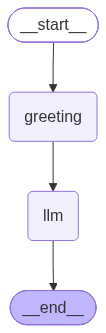

In [4]:
app

--- 
## 3. Conditional Edges & Dynamic Routing

Conditional edges allow your graph to dynamically choose the next node based on state contents (e.g. routing based on user sentiment, topic classification, or LLM output).

In [5]:
# Define router function
def route_by_topic(state: CustomState):
    last_message = state['messages'][-1].content.lower()
    if "python" in last_message or "code" in last_message:
        return "coding_node"
    else:
        return "general_node"

def coding_node(state: CustomState):
    res = llm.invoke([HumanMessage(content=f"Explain Python code concept for: {state['messages'][-1].content}")])
    return {"messages": [res]}

def general_node(state: CustomState):
    res = llm.invoke([HumanMessage(content=f"General conversational reply to: {state['messages'][-1].content}")])
    return {"messages": [res]}

# Build Router Graph
router_builder = StateGraph(CustomState)
router_builder.add_node("coding_node", coding_node)
router_builder.add_node("general_node", general_node)

# Add Conditional Edge from START
router_builder.add_conditional_edges(
    START,
    route_by_topic,
    {
        "coding_node": "coding_node",
        "general_node": "general_node"
    }
)
router_builder.add_edge("coding_node", END)
router_builder.add_edge("general_node", END)

router_app = router_builder.compile()

# Test Coding Route
res_code = router_app.invoke({"messages": [HumanMessage(content="What is a Python dictionary?")]})
print("--- Coding Route Response ---")
print(res_code['messages'][-1].content[:150], "...")

--- Coding Route Response ---
[{'type': 'text', 'text': 'In Python, a **dictionary** is a collection that stores data in **key-value pairs**. \n\nThink of it like a real-life dictionary: you look up a "word" (the **key**), and you get its "definition" (the **value**).\n\n---\n\n### 1. The Syntax\nDictionaries are defined using **curly braces `{}`**. Each key and value are separated by a colon `:`, and each pair is separated by a comma.\n\n```python\n# A simple dictionary\nstudent = {\n    "name": "Alice",\n    "age": 21,\n    "courses": ["Math", "Computer Science"]\n}\n```\n\n### 2. Key Characteristics\n*   **Key-Value Pairs:** Every piece of data has a label (key) associated with it.\n*   **Unique Keys:** Every key must be unique. If you try to create a duplicate key, the old one will be overwritten.\n*   **Mutable:** You can add, remove, or change items after the dictionary is created.\n*   **Efficient:** They are highly optimized for looking up values based on a key (very fast).\n\n

--- 
## 4. ReAct Agent Graph (`ToolNode` & `tools_condition`)

In LangGraph, agents are represented as cyclic graphs where the LLM node can loop to a `ToolNode` whenever tool execution is requested.

In [6]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

# 1. Define Tools
@tool
def calculate_area(length: float, width: float) -> float:
    """Calculate the area of a rectangle given length and width."""
    return length * width

@tool
def calculate_perimeter(length: float, width: float) -> float:
    """Calculate the perimeter of a rectangle given length and width."""
    return 2 * (length + width)

tools = [calculate_area, calculate_perimeter]

# 2. Bind Tools to LLM
llm_with_tools = llm.bind_tools(tools)

# 3. Define Agent Node
def agent_node(state: MessagesState):
    response = llm_with_tools.invoke(state['messages'])
    return {"messages": [response]}

# 4. Build Agent Graph
agent_builder = StateGraph(MessagesState)

# Add Agent & Tool Nodes
agent_builder.add_node("agent", agent_node)
agent_builder.add_node("tools", ToolNode(tools))

# Add Edges
agent_builder.add_edge(START, "agent")

# Add Conditional Edge: If LLM requests tool, go to 'tools', else go to END
agent_builder.add_conditional_edges("agent", tools_condition)

# Add Edge from tools back to agent (Cyclic Loop!)
agent_builder.add_edge("tools", "agent")

agent_app = agent_builder.compile()

# Run Agent Query
agent_res = agent_app.invoke({"messages": [HumanMessage(content="What is the area of a rectangle with length 15 and width 8?")]})
print("--- ReAct Agent Execution Output ---")
for msg in agent_res['messages']:
    print(f"[{msg.__class__.__name__}]: {msg.content}")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"   🛠 Tool Calls: {msg.tool_calls}")

--- ReAct Agent Execution Output ---
[HumanMessage]: What is the area of a rectangle with length 15 and width 8?
[AIMessage]: []
   🛠 Tool Calls: [{'name': 'calculate_area', 'args': {'length': 15, 'width': 8}, 'id': 'FUa3EzzN', 'type': 'tool_call'}]
[ToolMessage]: 120.0
[AIMessage]: [{'type': 'text', 'text': 'The area of a rectangle with a length of 15 and a width of 8 is 120.', 'extras': {'signature': 'EjQKMgERTTIPMjPhqg9anfR0BSZTtJpBwLgV1x7Ckc3b0Crr+zdGnifWUJDw5kRXheyCTgzC'}}]


--- 
## 5. State Persistence & Memory (`MemorySaver`)

By attaching a checkpointer like `MemorySaver`, LangGraph automatically saves state at every node execution per `thread_id`.

In [7]:
from langgraph.checkpoint.memory import MemorySaver

# Attach MemorySaver checkpointer
memory = MemorySaver()
persistent_agent = agent_builder.compile(checkpointer=memory)

# Define session thread configuration
config = {"configurable": {"thread_id": "user_session_99"}}

# Turn 1
t1_res = persistent_agent.invoke(
    {"messages": [HumanMessage(content="Hi! I am building a garden with length 20m and width 5m.")]},
    config=config
)
print("Turn 1 Response:", t1_res['messages'][-1].content)

# Turn 2 (Testing Memory Persistence across thread_id)
t2_res = persistent_agent.invoke(
    {"messages": [HumanMessage(content="What is the total area of my garden?")]},
    config=config
)
print("Turn 2 Response (Memory Check):")
print(t2_res['messages'][-1].content)

Turn 1 Response: [{'type': 'text', 'text': 'That sounds like a wonderful project! With a length of 20m and a width of 5m, here are the dimensions for your garden:\n\n*   **Total Area:** 100 square meters\n*   **Perimeter:** 50 meters\n\nAre you planning to grow anything specific in your garden?', 'extras': {'signature': 'EjQKMgERTTIP7jL+/egZm6cCAN37o89DELoa6eYui2GeYKY7FBP1gcMpxazI2Bu7k+YYzlmK'}}]
Turn 2 Response (Memory Check):
[{'type': 'text', 'text': 'The total area of your garden is 100 square meters.', 'extras': {'signature': 'EjQKMgERTTIPlzjh0CFCIm3O9e2dW8Gqns8Uv4dsCcuAEtJHkEfvlCahchlieN0L/DUewqaK'}}]


--- 
## 6. Human-in-the-Loop (HITL) & Interrupts

In critical workflows (e.g. financial transactions, database writes, or tool approvals), you can pause graph execution before executing specific nodes using `interrupt_before`.

In [8]:
# Compile graph with interrupt_before=['tools']
hitl_agent = agent_builder.compile(
    checkpointer=MemorySaver(),
    interrupt_before=["tools"]
)

hitl_config = {"configurable": {"thread_id": "approval_session_1"}}

# 1. Trigger query that requires tool execution
print("=== Invoking Query requiring tool call ===")
hitl_res = hitl_agent.invoke(
    {"messages": [HumanMessage(content="Calculate the perimeter of a rectangle with length 12 and width 4.")]},
    config=hitl_config
)

# 2. Inspect Pending State
state = hitl_agent.get_state(hitl_config)
print("=== Graph Interrupted! Pending Tasks ===")
print("Next Node to Execute:", state.next)
print("Pending Tool Call Request:", state.values['messages'][-1].tool_calls)

# 3. Resume Execution after Human Approval (pass None to continue)
print("=== Approving & Resuming Execution ===")
final_hitl_res = hitl_agent.invoke(None, config=hitl_config)
print("Final Output:", final_hitl_res['messages'][-1].content)

=== Invoking Query requiring tool call ===
=== Graph Interrupted! Pending Tasks ===
Next Node to Execute: ('tools',)
Pending Tool Call Request: [{'name': 'calculate_perimeter', 'args': {'width': 4, 'length': 12}, 'id': 'nAbjWmLl', 'type': 'tool_call'}]
=== Approving & Resuming Execution ===
Final Output: [{'type': 'text', 'text': 'The perimeter of a rectangle with a length of 12 and a width of 4 is 32.', 'extras': {'signature': 'EjQKMgERTTIPqt60LxkoiaqEO6jjNN+tGtHgGKa+NUWTdJB+w1GiJVOtcQGokySj6BEVEwmn'}}]


--- 
## 7. Time Travel & State Revision (`update_state`)

LangGraph records a checkpoint history for every turn. You can inspect past checkpoints and modify state parameters to branch execution!

In [ ]:
# 1. Inspect State Checkpoint History
history = list(hitl_agent.get_state_history(hitl_config))
print(f"Total Checkpoints Recorded for thread: {len(history)}")

# 2. Update/Revise State manually
print("=== Editing State Checkpoint ===")
# Example: We update state parameters or insert a system note
hitl_agent.update_state(
    hitl_config,
    {"messages": [HumanMessage(content="Note: Always respond politely with an emoji.")]}
)

# Check updated state
updated_state = hitl_agent.get_state(hitl_config)
print("Latest Message in State:", updated_state.values['messages'][-1].content)

--- 
## 8. Multi-Agent Systems (Supervisor Pattern)

In complex multi-agent architectures, a **Supervisor Node** acts as a manager that delegates tasks to specialized worker nodes.

In [ ]:
# Define Specialist Nodes
def math_specialist(state: MessagesState):
    prompt = f"You are a math expert. Solve concisely: {state['messages'][-1].content}"
    res = llm.invoke([HumanMessage(content=prompt)])
    return {"messages": [AIMessage(content=f"🧮 Math Agent: {res.content}")]}

def code_specialist(state: MessagesState):
    prompt = f"You are a Python expert. Provide a concise solution for: {state['messages'][-1].content}"
    res = llm.invoke([HumanMessage(content=prompt)])
    return {"messages": [AIMessage(content=f"🐍 Code Agent: {res.content}")]}

# Build Multi-Agent Graph
multi_builder = StateGraph(MessagesState)
multi_builder.add_node("math_agent", math_specialist)
multi_builder.add_node("code_agent", code_specialist)

# Supervisor Router
def supervisor_router(state: MessagesState):
    user_msg = state['messages'][-1].content.lower()
    if "code" in user_msg or "function" in user_msg or "python" in user_msg:
        return "code_agent"
    else:
        return "math_agent"

multi_builder.add_conditional_edges(
    START,
    supervisor_router,
    {
        "code_agent": "code_agent",
        "math_agent": "math_agent"
    }
)
multi_builder.add_edge("code_agent", END)
multi_builder.add_edge("math_agent", END)

multi_agent_app = multi_builder.compile()

# Test Supervisor Delegation
res_multi = multi_agent_app.invoke({"messages": [HumanMessage(content="Write a Python function to check if a string is a palindrome.")]})
print("--- Multi-Agent Execution Result ---")
print(res_multi['messages'][-1].content)

--- 
## 9. Summary & Next Steps

🎉 **Congratulations!** You have covered all modern, up-to-date concepts of **LangGraph**:
- `StateGraph` architecture, `START`, `END`, and `MessagesState`
- State Reducers (`add_messages`) and custom `TypedDict` state schemas
- Node definition, linear transitions, and conditional edge routing
- ReAct Agent Cyclic Graphs with `ToolNode` and `tools_condition`
- Persistence and Memory management with `MemorySaver` checkpointer
- Human-in-the-Loop (HITL) with `interrupt_before` and `get_state()`
- State revision and Time Travel using `update_state()` and `get_state_history()`
- Multi-Agent Orchestration with the Supervisor-Worker pattern

### ➡️ Next Tutorial Steps:
- **AutoGen 101**: Multi-agent conversational patterns and group chats with local Ollama models.